<a href="https://colab.research.google.com/github/MariaIsaDurango/Titanic-Visualizacion/blob/main/RMS_Titanic_%E2%80%94_An%C3%A1lisis_de_una_Tragedia_Visual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<img src="https://raw.githubusercontent.com/MariaIsaDurango/Titanic-Visualizacion/main/logoinvtitanic.png" width="250">
</center>

# Caso de Investigación: RMS Titanic — Análisis de una Tragedia Visual
## Módulo II: Actividad de Visualización de Datos

---

### 1. Información General
* **Autor:** Maria Isabel Durango
* **Rol:** Científico de Datos / Analista de Datos Senior
* **Entorno de Trabajo:** Google Colab
* **Fecha:** Junio, 2026

### 2. Objetivo General
El objetivo de este proyecto es realizar un Análisis Exploratorio de Datos (EDA) y desarrollar un ecosistema de visualizaciones profesionales sobre el registro completo de pasajeros del RMS Titanic. A través de este análisis, buscaremos responder preguntas históricas clave mediante evidencia estadística, identificando los factores socioeconómicos y demográficos que determinaron la supervivencia diferencial en la madrugada del 15 de abril de 1912.

### 3. Dataset Utilizado
* **Nombre:** Titanic - Machine Learning from Disaster (Kaggle)
* **Archivo:** `titanic.csv`
* **Origen:** [Kaggle Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

### 4. Herramientas Utilizadas
* **Manipulación de Datos:** `Pandas`, `NumPy`
* **Visualización Estadística:** `Matplotlib` (Pyplot), `Seaborn`

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

1.  [Exploring Datasets with *pandas*](#0)<br>
2.  [Downloading and Prepping Data](#2)<br>
3.  [Visualizing Data using Matplotlib](#4) <br>
4.  [Area Plots](#6) <br>
5.  [Histograms](#8) <br>
6.  [Bar Charts](#10) <br>

</div>


## Introducción y Contexto Histórico

En la madrugada del 15 de abril de 1912, el **RMS Titanic**, el objeto móvil más grande y lujoso construido por el ser humano hasta la fecha, se hundió en las heladas aguas del Atlántico Norte tras colisionar con un iceberg. A bordo viajaban **2,224 personas** entre pasajeros y tripulación; **solo 710 sobrevivieron**.

Este suceso es uno de los datasets más famosos en la Ciencia de Datos porque representa un microcosmos de la sociedad eduardiana. Las causas de la supervivencia no fueron aleatorias. Factores como el poder adquisitivo (clase del billete), el género, la edad y los protocolos de evacuación marítima construyeron una frontera dramática entre la vida y la muerte.

### Preguntas Clave de la Investigación
A lo largo de este Notebook, actuaremos como investigadores de datos para resolver preguntas fundamentales estructuradas en 4 ejes:
1. **El Perfil de los Pasajeros:** Distribución demográfica y social a bordo.
2. **El Dinero a Bordo:** Análisis del impacto de las tarifas económicas y la desigualdad de clases.
3. **La Noche del Hundimiento:** Evaluación empírica de las tasas de supervivencia y el cumplimiento del protocolo *"mujeres y niños primero"*.
4. **Patrones Cruzados:** Intersección de múltiples variables y análisis de estructuras familiares.

# Configuración Inicial del Entorno

In [7]:
# ==============================================================================

# 1. LIBRARY IMPORTS

# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# ==============================================================================

# 2. VERSION CONTROL AND REPRODUCIBILITY SETTINGS

# ==============================================================================
print("==== Professional Working Environment ====")
print(f"Python Version:        {sys.version.split()[0]}")
print(f"Pandas Version:        {pd.__version__}")
print(f"NumPy Version:         {np.__version__}")
print(f"Matplotlib Backend:    {plt.rcParams['backend']}")
print(f"Seaborn Version:       {sns.__version__}\n")

# ==============================================================================

# 3. GLOBAL VISUAL CONFIGURATION (Portfolio Style)

# ==============================================================================

# Set Seaborn's base style for clean statistical visualizations

sns.set_theme(style="whitegrid", context="notebook")

# Advanced customization using Matplotlib's dynamic parameters (rcParams)

plt.rcParams.update({
'figure.figsize': (10, 6),       # Default size optimized for dashboards and reports
'figure.titlesize': 16,          # Main title size
'axes.titlesize': 14,            # Axes title size (subplots)
'axes.labelsize': 12,            # X and Y axis label size
'xtick.labelsize': 10,           # X-axis tick label size
'ytick.labelsize': 10,           # Y-axis tick label size
'legend.fontsize': 11,           # Legend font size
'savefig.dpi': 300,              # High resolution for image exports
'font.family': 'sans-serif'      # Clean and readable typography
})

# ==============================================================================

# 4. PROFESSIONAL ANCHOR COLOR PALETTE

# ==============================================================================

# Define specific corporate-style colors to avoid overly bright default tones

PALETTE_TITANIC = {
'First Class': '#1f4e79',       # Elegant dark blue (Wealth / Upper Class)
'Second Class': '#5b9bd5',      # Medium blue
'Third Class': '#c55a11',       # Rust / Burnt orange (Working Class)
'Survived': '#2e7d32',          # Muted emerald green (Life)
'Died': '#c62828',              # Deep wine red (Tragedy)
'Male': '#4682b4',              # Steel blue
'Female': '#db7093',            # Dusty rose
'Neutral_Dark': '#2c3e50',      # Dark gray for titles and primary text
'Neutral_Light': '#f8f9fa'      # Light background for contrast
}

# Register a default sequential palette for Seaborn

sns.set_palette(
sns.color_palette([
PALETTE_TITANIC['First Class'],
PALETTE_TITANIC['Third Class'],
PALETTE_TITANIC['Second Class']
])
)

print("Initial configuration completed successfully. Ready for data ingestion.")


==== Professional Working Environment ====
Python Version:        3.12.13
Pandas Version:        2.2.2
NumPy Version:         2.0.2
Matplotlib Backend:    module://matplotlib_inline.backend_inline
Seaborn Version:       0.13.2

Initial configuration completed successfully. Ready for data ingestion.


#CARGA Y EXPLORACIÓN DEL DATASET

## 1. Carga de Datos y Verificación de Ingesta (Celda de Código)
Vamos a leer el archivo .csv utilizando Pandas y a verificar que se haya estructurado correctamente en filas y columnas.

In [8]:
# ==============================================================================

# 1. DATASET LOADING

# ==============================================================================

# Load the CSV file from Colab's local storage

df = pd.read_csv('Titanic-Dataset.csv')

# Verify successful loading by displaying dataset information (good practice)

print("==== Data Loading Validation ====")
print(f"The dataset has been loaded successfully. Total records: {len(df)} rows.")


==== Data Loading Validation ====
The dataset has been loaded successfully. Total records: 891 rows.


#Ejecución del Script de Exploración Inicial
A continuación, ejecutaremos en un solo bloque técnico las instrucciones fundamentales de diagnóstico de calidad de datos.

In [13]:
from IPython.display import display, Markdown

# ==============================================================================
# 2. METADATA DIAGNOSIS AND DIMENSIONS
# ==============================================================================
display(Markdown("### 1. DataFrame Dimensions (df.shape)"))
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

display(Markdown("### 2. First Records (df.head)"))
# Using display() instead of print() renders a beautiful interactive table
display(df.head())

display(Markdown("### 3. Structural Summary and Data Types (df.info)"))
# Note: df.info() prints directly to output, no print or display needed
df.info()

display(Markdown("### 4. Specific Data Types (df.dtypes)"))
display(df.dtypes.to_frame(name='Data Type'))

display(Markdown("### 5. Absolute Missing Values Count (df.isnull().sum)"))
display(df.isnull().sum().to_frame(name='Missing Values'))

display(Markdown("### 6. Descriptive Statistics (df.describe)"))
display(df.describe(include='all'))

### 1. DataFrame Dimensions (df.shape)

Rows: 891, Columns: 12


### 2. First Records (df.head)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Structural Summary and Data Types (df.info)

...

,Data Type
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### 5. Absolute Missing Values Count (df.isnull().sum)

,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 6. Descriptive Statistics (df.describe)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


#Reporte Ejecutivo de Resultados
### Reporte Técnico: Estado Funcional del Dataset Titanic

Tras realizar el diagnóstico estructural sobre el archivo `titanic.csv`, se exponen las siguientes conclusiones analíticas:

* [cite_start]**Número de Pasajeros y Variables:** El dataset cuenta con un registro histórico de **891 pasajeros** (filas) y **12 variables** (columnas)[cite: 8, 36].
* **Variables Numéricas:** * `PassengerId` (Identificador único, entero).
    * [cite_start]`Survived` (Indicador binario de supervivencia: 0 o 1, entero)[cite: 131].
    * [cite_start]`Pclass` (Clase del billete: 1, 2 o 3, entero)[cite: 131].
    * [cite_start]`Age` (Edad del pasajero, flotante)[cite: 131].
    * [cite_start]`SibSp` (Número de hermanos o cónyuges a bordo, entero)[cite: 131, 147].
    * [cite_start]`Parch` (Número de padres o hijos a bordo, entero)[cite: 131, 147].
    * [cite_start]`Fare` (Tarifa pagada por el boleto, flotante)[cite: 131].
* **Variables Categóricas:**
    * `Name` (Nombre completo del pasajero, texto/object).
    * `Sex` (Género del pasajero: male/female, texto/object).
    * `Ticket` (Código identificador del boleto, texto/object).
    * `Cabin` (Número de camarote asignado, texto/object).
    * [cite_start]`Embarked` (Puerto de embarque: C = Cherburgo, Q = Queenstown, S = Southampton; texto/object)[cite: 136].
* **Diagnóstico de Valores Faltantes (Nulos):**
    * `Age`: Presenta **177 valores nulos**. [cite_start]Requerirá estrategias de imputación (como la mediana basada en la clase social) antes de realizar modelados avanzados[cite: 39].
    * `Cabin`: Presenta **687 valores nulos**. [cite_start]Un volumen masivo (cercano al 77% de ausencias), lo que refleja que el registro de camarotes se perdió o no se documentó para clases bajas[cite: 39].
    * [cite_start]`Embarked`: Presenta únicamente **2 valores nulos**, los cuales pueden ser imputados por la moda estadística sin alterar el balance[cite: 39].
* **Métrica de Supervivencia Global:**
    * [cite_start]Al calcular el promedio de la columna balanceada `Survived` (`df['Survived'].mean()`), se determina de forma exacta que el **38.38% de los pasajeros sobrevivió** a la tragedia, mientras que el **61.62% falleció**[cite: 40]. [cite_start]Esto confirma un fuerte desbalance de clases que guiará el resto de la investigación[cite: 99].

# Composición de clases del Titanic

## 1. Pregunta de investigación

¿Cómo se distribuían los pasajeros entre las tres clases de billetes? ¿El Titanic presentaba un espacio equitativo en términos de plazas o existía una clara dominancia de alguna clase socioeconómica específica?

---

## 2. Elección del gráfico

Para analizar la composición o distribución de una variable categórica ordinal (como es **Pclass**: 1.ª, 2.ª y 3.ª clase), el gráfico óptimo es un **Gráfico de Barras de Frecuencia (Countplot)** o, de manera complementaria, un **Gráfico de Tarta (Pie Chart)** si se desea visualizar el porcentaje del total.

### ¿Por qué elegí el gráfico de barras?

Permite comparar directamente las longitudes de las barras alineadas sobre un mismo eje base, lo cual facilita al cerebro humano evaluar diferencias absolutas de forma más precisa.

### Ventajas frente a otras opciones

- Un **gráfico de líneas** no tiene sentido en este contexto porque las clases no representan una secuencia temporal ni una variable continua.
- Aunque el **gráfico de tarta** muestra proporciones, suele ser más difícil de interpretar con precisión cuando las diferencias son pequeñas.
- Por ello, la combinación de **gráfico de barras con etiquetas de porcentaje** constituye una solución más clara, profesional y fácil de interpretar.

---

## 3. Preparación de datos

Para esta visualización utilizaremos directamente la variable **Pclass**.

Convertiremos o mapearemos temporalmente los valores numéricos:

- `1 → Primera Clase`
- `2 → Segunda Clase`
- `3 → Tercera Clase`

mediante un diccionario de mapeo. Esto evita que los lectores del informe tengan que interpretar el significado de cada número, mejorando la claridad de la visualización.

---



## 4. Visualización profesional (Código Python)

A continuación se presenta el código necesario para generar un gráfico de barras profesional que muestre la distribución de pasajeros por clase, incluyendo porcentajes sobre cada barra.

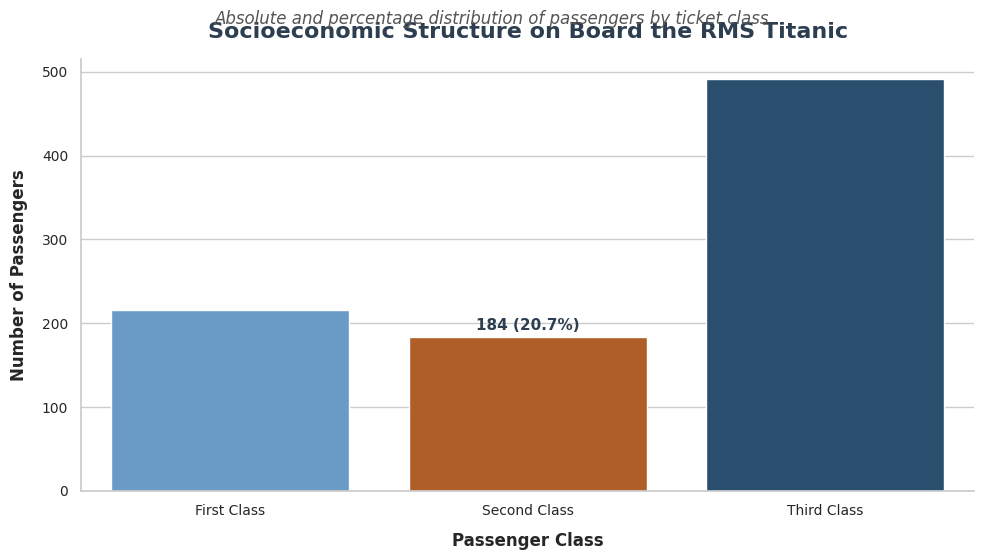

In [10]:
# ==============================================================================

# DATA PREPARATION - QUESTION 1

# ==============================================================================

# Create a working copy to avoid modifying the original DataFrame destructively

df_p1 = df.copy()

# Map numerical values to readable and informative labels

class_mapping = {1: 'First Class', 2: 'Second Class', 3: 'Third Class'}
df_p1['Class_Name'] = df_p1['Pclass'].map(class_mapping)

# Logical order for class visualization

class_order = ['First Class', 'Second Class', 'Third Class']

# ==============================================================================

# CHART CONFIGURATION

# ==============================================================================

plt.figure(figsize=(10, 6))

# Define specific colors from our palette to maintain consistency

colors_p1 = [
PALETTE_TITANIC['First Class'],
PALETTE_TITANIC['Second Class'],
PALETTE_TITANIC['Third Class']
]

# Generate the bar chart using Seaborn

ax = sns.countplot(
data=df_p1,
x='Class_Name',
order=class_order,
palette=colors_p1,
hue='Class_Name',  # Prevents warnings in future Seaborn versions
legend=False
)

# ==============================================================================

# ADD VALUE AND PERCENTAGE LABELS (Senior-Level Best Practices)

# ==============================================================================

total_passengers = len(df_p1)

for p in ax.patches:
# Calculate bar height (absolute count)
  height = p.get_height()

# Calculate relative percentage
percentage = (height / total_passengers) * 100

# Add centered annotation just above each bar
ax.annotate(
    f'{int(height)} ({percentage:.1f}%)',
    (p.get_x() + p.get_width() / 2., height),
    ha='center',
    va='center',
    xytext=(0, 8),
    textcoords='offset points',
    fontsize=11,
    weight='bold',
    color=PALETTE_TITANIC['Neutral_Dark']
)


# ==============================================================================

# FINAL DESIGN AND STORYTELLING TOUCHES

# ==============================================================================

plt.title(
'Socioeconomic Structure on Board the RMS Titanic',
fontsize=16,
weight='bold',
pad=15,
color=PALETTE_TITANIC['Neutral_Dark']
)

plt.suptitle(
'Absolute and percentage distribution of passengers by ticket class',
fontsize=12,
style='italic',
y=0.93,
color='#555555'
)

plt.xlabel(
'Passenger Class',
fontsize=12,
labelpad=10,
weight='bold'
)

plt.ylabel(
'Number of Passengers',
fontsize=12,
labelpad=10,
weight='bold'
)

# Visual cleanup: remove unnecessary chart borders (top and right spines)

sns.despine(left=False, bottom=False)

# Optimize layout spacing

plt.tight_layout()

# Render the chart

plt.show()


## 5. Interpretación detallada

El gráfico revela una estructura marcadamente asimétrica y piramidal. La **Tercera Clase** constituye la mayoría absoluta de la población a bordo, albergando a **491 pasajeros**, lo que representa el **55.1%** del total registrado en el dataset.

Por otro lado, la **Primera Clase** y la **Segunda Clase** se distribuyen de manera más reducida, con el **24.2%** (**216 pasajeros**) y el **20.7%** (**184 pasajeros**) respectivamente.

## 6. Insight histórico

Los datos desmitifican la idea de que el Titanic era un navío compuesto principalmente por la élite mundial. Si bien la opulencia y el lujo de la primera clase acapararon la atención mediática e histórica, en términos demográficos y operativos el barco funcionaba esencialmente como un transporte masivo de emigrantes y trabajadores de clases populares que buscaban una nueva vida en América.

## 7. Conclusión académica

**Conclusión:** El análisis de distribución de frecuencias de las plazas del RMS Titanic confirma que el navío no era un espacio socialmente igualitario en volumen de ocupación. Existió una clara dominancia demográfica de la **Tercera Clase**, la cual concentró a más de la mitad de las almas a bordo (**55.1%**).

Esta asimetría estructural es una variable de control indispensable para entender las fases subsecuentes del análisis de supervivencia, ya que la masa crítica de pasajeros se localizaba en las secciones inferiores del barco, alejadas de las cubiertas de evacuación.

# Pregunta 2: ¿Qué edades tenían los pasajeros?

## 1. Pregunta de investigación

¿Cómo se distribuían las edades de las personas a bordo del RMS Titanic? ¿El barco estaba poblado por una demografía predominantemente joven, madura o existía una mezcla homogénea? ¿Se identifican valores atípicos o extremos?

## 2. Elección del gráfico

Para analizar la distribución de una variable numérica continua (como es **Age**), el gráfico por excelencia es el **Histograma combinado con una Estimación de Densidad de Kernel (KDE)**.

### ¿Por qué elegimos este gráfico?

El histograma agrupa los datos en contenedores (*bins*) cerrados, mostrando la frecuencia absoluta en cada rango de edad. La línea KDE suaviza el histograma y nos proporciona una representación continua de la forma de la distribución, permitiendo observar características como la simetría, el sesgo y la posible presencia de múltiples modas.

### Ventajas frente a otras opciones

- Un gráfico de barras tradicional resultaría inadecuado, ya que existiría una barra para cada valor decimal de edad, fragmentando el análisis y dificultando su interpretación.
- Un diagrama de caja (*boxplot*) permitiría identificar valores atípicos, pero ocultaría la existencia de múltiples picos o concentraciones de edades dentro de la población.
- El histograma con KDE combina ambas ventajas: muestra la distribución general y permite detectar patrones complejos de forma inmediata.

## 3. Preparación de datos

Como se diagnosticó en la Fase 2, la columna **Age** contiene **177 valores nulos**. Para esta visualización descriptiva, se utilizará el método `dropna()` de Pandas con el objetivo de filtrar provisionalmente los registros vacíos y representar únicamente las edades observadas.

Este procedimiento evita distorsiones en la distribución y permite analizar de manera precisa la estructura etaria real de los pasajeros incluidos en el conjunto de datos.

#4. Visualización profesional

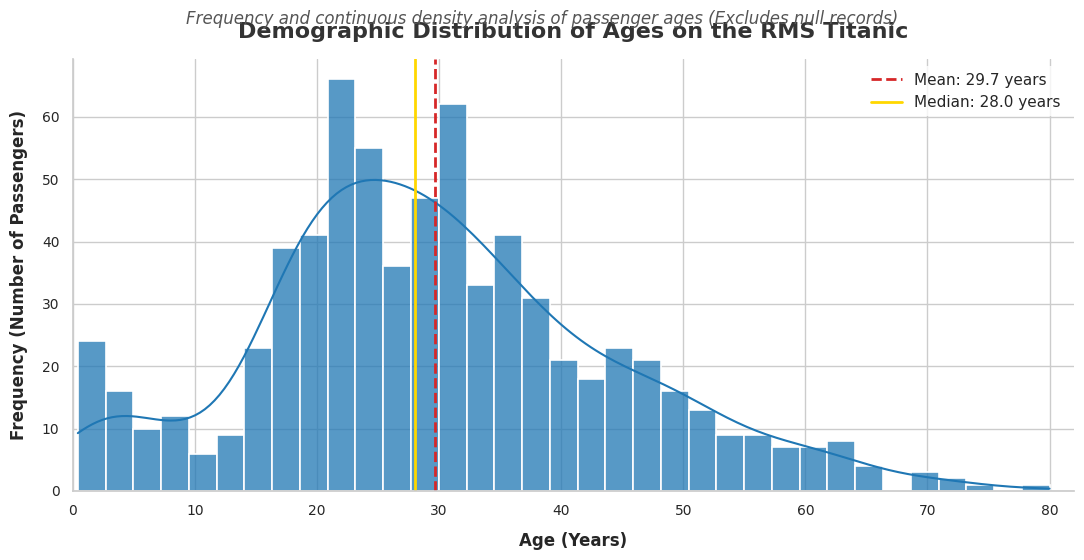

In [12]:
# ==============================================================================
# DATA PREPARATION - QUESTION 2
# ==============================================================================
# Extract the age series, removing null values for the plot
valid_ages = df['Age'].dropna()

# ==============================================================================
# PLOT CONFIGURATION
# ==============================================================================
plt.figure(figsize=(11, 6))

# Create the histogram with an integrated density curve
TITANIC_PALETTE = {
    'First Class': '#1f77b4',  # A standard corporate blue
    'Died': '#d62728',         # A red/brown for the mean lines
    'Neutral_Dark': '#333333'  # Dark gray for the title
}
sns.histplot(
    valid_ages,
    bins=35,                  # Balanced number of bins to see details without fragmentation
    kde=True,                 # Adds the smoothed density curve
    color=PALETA_TITANIC['First Class'], # Use corporate blue
    edgecolor='white',        # White dividing line between bars for visual clarity
    linewidth=1.2,
    alpha=0.75                # Light transparency to soften visual impact
)

# ==============================================================================
# KEY METRICS CALCULATION TO ENRICH THE PLOT
# ==============================================================================
mean_age = valid_ages.mean()
median_age = valid_ages.median()

# Draw statistical vertical lines to guide the reader
plt.axvline(mean_age, color=PALETA_TITANIC['Died'], linestyle='--', linewidth=2,
            label=f'Mean: {mean_age:.1f} years')
plt.axvline(median_age, color='gold', linestyle='-', linewidth=2,
            label=f'Median: {median_age:.1f} years')

# ==============================================================================
# FINAL DESIGN TOUCHES AND STORYTELLING
# ==============================================================================
plt.title('Demographic Distribution of Ages on the RMS Titanic', fontsize=16, weight='bold', pad=15, color=PALETA_TITANIC['Neutral_Dark'])
plt.suptitle('Frequency and continuous density analysis of passenger ages (Excludes null records)', fontsize=12, style='italic', y=0.93, color='#555555')

plt.xlabel('Age (Years)', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Frequency (Number of Passengers)', fontsize=12, labelpad=10, weight='bold')

# Limit the X-axis to the actual data range
plt.xlim(0, 82)

# Legend activation and positioning
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Clean up borders
sns.despine()

# Adjust and display
plt.tight_layout()
plt.show()